# Formativa 2 - Modelamiento Predictivo mediante Regresión Logística

**Asignatura:** MCDI501 – Estadística Computacional para la Toma de Decisiones

**Magíster en Ciencia de Datos e Inteligencia Artificial**

**Universidad Andrés Bello**

---

## Objetivo

Desarrollar un modelo de regresión logística para predecir el riesgo de enfermedad coronaria a diez años utilizando el conjunto de datos *Framingham Heart Study*, integrando explícitamente los resultados obtenidos durante la Sumativa 1 y la Sumativa 2.

---

## Integración con las fases anteriores

Durante la **Sumativa 1** se realizó el análisis exploratorio de datos, la estadística descriptiva, la estimación puntual, la construcción de intervalos de confianza y las pruebas de hipótesis.

Durante la **Sumativa 2** se validaron dichos resultados mediante técnicas de remuestreo (bootstrap), pruebas de permutación, simulación Monte Carlo y análisis de robustez.

En esta Formativa 2 se utilizarán estos resultados para fundamentar la selección de variables, el tratamiento de los datos y la construcción del primer modelo predictivo mediante regresión logística, preparando la base para la Sumativa 3.

# 1. Importación de librerías

In [2]:
# ==========================================
# Librerías generales
# ==========================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# ==========================================
# Scikit-learn
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ==========================================
# Statsmodels
# ==========================================

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# ==========================================
# Configuración general
# ==========================================

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8,5)

print("=" * 60)
print("Librerías cargadas correctamente")
print("=" * 60)
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {__import__('sklearn').__version__}")
print(f"Statsmodels  : {sm.__version__}")

Librerías cargadas correctamente
NumPy        : 2.4.6
Pandas       : 3.0.3
Scikit-learn : 1.9.0
Statsmodels  : 0.14.6


# 2. Carga del conjunto de datos

## Carga y verificación del conjunto de datos

En esta sección se carga el conjunto de datos **Framingham Heart Study**, utilizado durante todas las fases del proyecto.

Se verifica que el archivo exista correctamente y posteriormente se inspeccionan sus dimensiones, estructura y variables disponibles antes de iniciar el proceso de modelamiento.

## Configuración del proyecto

En esta sección se definen las rutas de trabajo utilizadas durante la Formativa 2.

La configuración permite localizar automáticamente el conjunto de datos utilizado en las fases anteriores y crear las carpetas de resultados necesarias para el desarrollo del proyecto.

In [3]:
# ==========================================
# Configuración de rutas del proyecto
# ==========================================

from pathlib import Path

# Buscar automáticamente la carpeta raíz del proyecto
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "mcdi501_grupo6":
    PROJECT_ROOT = PROJECT_ROOT.parent

# ==========================================
# Dataset
# ==========================================

DATA_PATH = PROJECT_ROOT / "datos" / "original" / "framingham.csv"

# ==========================================
# Carpetas de la Formativa 2
# ==========================================

RESULTS_DIR = PROJECT_ROOT / "F4" / "formativa2" / "results"

FIGURES_DIR = PROJECT_ROOT / "F4" / "formativa2" / "figures"

# Crear carpetas si no existen
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# Mostrar configuración
# ==========================================

print("=" * 60)
print("Configuración del proyecto")
print("=" * 60)

print(f"Proyecto    : {PROJECT_ROOT}")
print(f"Dataset     : {DATA_PATH}")
print(f"Resultados  : {RESULTS_DIR}")
print(f"Figuras     : {FIGURES_DIR}")

Configuración del proyecto
Proyecto    : C:\users\pablo\documents\mcdi501_grupo6
Dataset     : C:\users\pablo\documents\mcdi501_grupo6\datos\original\framingham.csv
Resultados  : C:\users\pablo\documents\mcdi501_grupo6\F4\formativa2\results
Figuras     : C:\users\pablo\documents\mcdi501_grupo6\F4\formativa2\figures


## Configuración general del análisis

Se definen los parámetros globales que serán utilizados durante todo el proceso de modelamiento. Esto permite mantener la reproducibilidad y consistencia del análisis en todas las etapas.

In [4]:
# ==========================================
# Parámetros generales del análisis
# ==========================================

# Semilla para reproducibilidad
SEED = 42

# Proporción del conjunto de prueba (30 %)
TEST_SIZE = 0.30

# Nivel de significancia
ALPHA = 0.05

print("=" * 60)
print("Parámetros del análisis")
print("=" * 60)
print(f"Semilla aleatoria      : {SEED}")
print(f"Conjunto de prueba     : {TEST_SIZE:.0%}")
print(f"Nivel de significancia : {ALPHA}")

Parámetros del análisis
Semilla aleatoria      : 42
Conjunto de prueba     : 30%
Nivel de significancia : 0.05


In [5]:
# ==========================================
# Carga del conjunto de datos
# ==========================================

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Conjunto de datos cargado correctamente")
print("=" * 60)

print(f"Número de filas     : {df.shape[0]}")
print(f"Número de columnas  : {df.shape[1]}")

Conjunto de datos cargado correctamente
Número de filas     : 4238
Número de columnas  : 16


## Inspección inicial

Antes de preparar los datos para el modelamiento se revisa la estructura general del conjunto de datos, incluyendo nombres de variables, tipos de datos y una muestra de los primeros registros.

In [6]:
# ==========================================
# Inspección inicial
# ==========================================

display(df.head())

print("\nTipos de datos\n")
display(df.dtypes)

print("\nResumen del DataFrame\n")
df.info()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0



Tipos de datos



male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


Resumen del DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


## Resumen de la calidad de los datos

La evaluación detallada de la calidad del conjunto de datos fue desarrollada durante la Sumativa 1.

Los principales hallazgos fueron:

- Existencia de valores faltantes en algunas variables clínicas.
- Presencia de valores atípicos principalmente en variables continuas.
- Variables numéricas y categóricas correctamente identificadas.
- Conjunto de datos apto para el desarrollo de modelos predictivos.

Durante esta actividad se utilizarán dichos resultados para definir la estrategia de preparación de datos previa al modelamiento.

# 3. Integración de resultados de la Sumativa 1 y Sumativa 2

## Integración metodológica de las fases anteriores

La construcción del modelo predictivo no constituye un análisis independiente, sino la continuación del trabajo desarrollado durante las fases anteriores del proyecto.

### Resultados incorporados desde la Sumativa 1

Durante la Sumativa 1 se identificaron las principales características estadísticas del conjunto de datos mediante:

- Estadística descriptiva.
- Análisis exploratorio de datos.
- Estimación puntual e intervalos de confianza.
- Pruebas de hipótesis.
- Identificación de valores faltantes.
- Identificación de valores atípicos.
- Análisis de correlaciones entre variables clínicas.

### Resultados incorporados desde la Sumativa 2

Durante la Sumativa 2 se validaron dichos resultados mediante métodos computacionales, incorporando:

- Bootstrap para validar intervalos de confianza.
- Test de permutación para validar pruebas de hipótesis.
- Bootstrap de correlaciones para evaluar estabilidad.
- Simulación Monte Carlo.
- Análisis de sensibilidad frente a valores atípicos.
- Validación de parámetros robustos para el modelamiento.

Todos estos antecedentes servirán como fundamento para la selección de variables predictoras y la construcción del modelo de regresión logística.

## Variables seleccionadas para el modelamiento

La selección inicial de variables predictoras se fundamenta en los resultados obtenidos durante las fases anteriores.

Las variables fueron elegidas considerando:

- Resultados de las pruebas de hipótesis de la Sumativa 1.
- Correlaciones validadas durante la Sumativa 2.
- Robustez observada mediante bootstrap y análisis de sensibilidad.
- Relevancia clínica de cada predictor.

La justificación estadística de cada variable será presentada antes del ajuste del modelo.

# 4. Preparación de datos para el modelamiento

## Estrategia de preparación de datos

La preparación del conjunto de datos se basa en los resultados obtenidos durante las fases anteriores del proyecto.

En la Sumativa 1 se identificó la presencia de valores faltantes y valores atípicos en algunas variables clínicas.

Durante la Sumativa 2 se verificó que las principales conclusiones estadísticas eran robustas frente a dichos valores mediante bootstrap, simulación Monte Carlo y análisis de sensibilidad.

Para esta actividad se utilizará una estrategia simple de eliminación de registros con valores faltantes (`dropna`), permitida por la rúbrica y suficiente para construir el primer modelo predictivo.

Las estrategias de imputación serán comparadas posteriormente durante la Sumativa 3.

In [7]:
# ==========================================
# Valores faltantes
# ==========================================

print("=" * 60)
print("Valores faltantes por variable")
print("=" * 60)

display(df.isnull().sum())

print("\nNúmero total de registros:", len(df))

# Eliminación de filas con valores faltantes
df_model = df.dropna().copy()

print("\nNúmero de registros después de dropna:", len(df_model))

print("\nRegistros eliminados:", len(df) - len(df_model))

print("\nPorcentaje conservado: {:.2f}%".format(
    len(df_model) / len(df) * 100
))

Valores faltantes por variable


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


Número total de registros: 4238

Número de registros después de dropna: 3656

Registros eliminados: 582

Porcentaje conservado: 86.27%


In [8]:
# ==========================================
# Eliminación de registros con valores faltantes
# ==========================================

df_model = df.dropna().copy()

print("=" * 60)
print("Tratamiento de valores faltantes")
print("=" * 60)

print(f"Registros originales        : {len(df)}")

print(f"Registros después de dropna : {len(df_model)}")

print(f"Registros eliminados        : {len(df)-len(df_model)}")

print(f"Porcentaje conservado       : {len(df_model)/len(df)*100:.2f}%")

Tratamiento de valores faltantes
Registros originales        : 4238
Registros después de dropna : 3656
Registros eliminados        : 582
Porcentaje conservado       : 86.27%


In [9]:
# ==========================================
# Verificación posterior al tratamiento
# ==========================================

faltantes = df_model.isnull().sum().sum()

print("=" * 60)
print("Verificación final")
print("=" * 60)

print(f"Valores faltantes restantes : {faltantes}")

if faltantes == 0:
    print("No existen valores faltantes.")
else:
    print("Aún existen valores faltantes.")

Verificación final
Valores faltantes restantes : 0
No existen valores faltantes.


## Justificación de las variables predictoras

La selección de las variables utilizadas en el primer modelo de regresión logística se fundamenta en los resultados obtenidos durante las Sumativas 1 y 2.

Se priorizaron variables con evidencia estadística, estabilidad mediante remuestreo y relevancia clínica, evitando incorporar simultáneamente variables altamente correlacionadas que pudieran afectar la estabilidad del modelo.

In [10]:
# ==========================================
# Justificación de las variables predictoras
# ==========================================

tabla_variables = pd.DataFrame({

    "Variable": [
        "age",
        "sysBP",
        "BMI",
        "glucose",
        "male"
    ],

    "Justificación": [

        "Factor de riesgo ampliamente documentado y asociado al desarrollo de enfermedad coronaria.",

        "Presentó diferencias estadísticamente significativas en S1 y resultados robustos en S2.",

        "Variable clínica relevante validada mediante bootstrap.",

        "Mostró diferencias importantes entre grupos y estabilidad mediante remuestreo.",

        "Variable demográfica utilizada para controlar posibles diferencias entre pacientes."

    ],

    "Fundamento": [

        "S1",

        "S1 + S2",

        "S2",

        "S1 + S2",

        "Conocimiento clínico"

    ]

})

display(tabla_variables)

,Variable,Justificación,Fundamento
0,age,Factor de riesgo ampliamente documentado y aso...,S1
1,sysBP,Presentó diferencias estadísticamente signific...,S1 + S2
2,BMI,Variable clínica relevante validada mediante b...,S2
3,glucose,Mostró diferencias importantes entre grupos y ...,S1 + S2
4,male,Variable demográfica utilizada para controlar ...,Conocimiento clínico


In [11]:
# ==========================================
# Variables del modelo
# ==========================================

features = [

    "age",

    "sysBP",

    "BMI",

    "glucose",

    "male"

]

target = "TenYearCHD"

X = df_model[features]

y = df_model[target]

print("=" * 60)
print("Variables seleccionadas")
print("=" * 60)

print("Variables predictoras:")

for variable in features:
    print(f" - {variable}")

print(f"\nVariable objetivo: {target}")

print(f"\nNúmero de predictores: {X.shape[1]}")

Variables seleccionadas
Variables predictoras:
 - age
 - sysBP
 - BMI
 - glucose
 - male

Variable objetivo: TenYearCHD

Número de predictores: 5


# 5. Construcción del modelo de regresión logística

## División del conjunto de datos

De acuerdo con la rúbrica de la actividad, el conjunto de datos se divide en un subconjunto de entrenamiento (70 %) y un subconjunto de prueba (30 %).

La partición se realiza utilizando una semilla fija para garantizar la reproducibilidad del análisis.

In [12]:
# ==========================================
# División entrenamiento / prueba
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

print("=" * 60)
print("División del conjunto de datos")
print("=" * 60)

print(f"Entrenamiento : {X_train.shape[0]} registros")
print(f"Prueba        : {X_test.shape[0]} registros")

print("\nVariables predictoras:", X_train.shape[1])

División del conjunto de datos
Entrenamiento : 2559 registros
Prueba        : 1097 registros

Variables predictoras: 5


## Estandarización de variables numéricas

Las variables numéricas se estandarizan utilizando la media y desviación estándar calculadas sobre el conjunto de entrenamiento.

La variable categórica **male** no se estandariza, ya que corresponde a una variable binaria.

In [13]:
# ==========================================
# Estandarización
# ==========================================

# Variables numéricas
variables_numericas = [
    "age",
    "sysBP",
    "BMI",
    "glucose"
]

# Variable binaria
variables_binarias = [
    "male"
]

scaler = StandardScaler()

# Copias para no modificar los datos originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Escalar únicamente variables numéricas
X_train_scaled[variables_numericas] = scaler.fit_transform(
    X_train[variables_numericas]
)

X_test_scaled[variables_numericas] = scaler.transform(
    X_test[variables_numericas]
)

print("=" * 60)
print("Variables estandarizadas correctamente")
print("=" * 60)

display(X_train_scaled.head())

Variables estandarizadas correctamente


,age,sysBP,BMI,glucose,male
3610,0.168272,0.179990,-1.016609,-0.353719,0
488,-0.648158,0.756510,-0.511255,0.193127,0
210,-0.531525,-0.396529,-1.354323,-0.308148,1
16,-0.181626,0.224338,-0.844108,-0.444859,1
1255,1.217967,-0.174791,-0.895130,-0.308148,1


In [14]:
# ==========================================
# Verificación final de los conjuntos
# ==========================================

print("=" * 60)
print("Resumen de los conjuntos")
print("=" * 60)

print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")

print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Resumen de los conjuntos
X_train : (2559, 5)
X_test  : (1097, 5)
y_train : (2559,)
y_test  : (1097,)


## Diagnóstico de multicolinealidad

Antes de ajustar el modelo de regresión logística se evalúa la posible existencia de multicolinealidad entre las variables predictoras mediante el **Factor de Inflación de la Varianza (VIF)**.

Como referencia general:

- **VIF < 5:** no existe evidencia importante de multicolinealidad.
- **VIF entre 5 y 10:** posible multicolinealidad moderada.
- **VIF > 10:** multicolinealidad alta, que puede afectar la estabilidad del modelo.

In [15]:
# ==========================================
# Diagnóstico de multicolinealidad (VIF)
# ==========================================

# Agregar constante
X_vif = sm.add_constant(X_train_scaled)

# Calcular VIF
vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

print("=" * 60)
print("Factor de Inflación de la Varianza (VIF)")
print("=" * 60)

display(vif)

Factor de Inflación de la Varianza (VIF)


,Variable,VIF
0,const,1.814280
1,age,1.158085
2,sysBP,1.291680
3,BMI,1.136523
4,glucose,1.024371
5,male,1.008766


### Interpretación

Los valores obtenidos permiten evaluar el grado de dependencia lineal entre las variables predictoras.

En caso de que todas las variables presenten un **VIF inferior a 5**, se considera que no existe evidencia importante de multicolinealidad, por lo que es apropiado incorporarlas simultáneamente en el modelo de regresión logística.

## Ajuste del modelo de regresión logística

Una vez verificada la ausencia de problemas importantes de multicolinealidad, se ajusta un modelo de regresión logística utilizando las variables seleccionadas.

El modelo se estima mediante máxima verosimilitud utilizando la implementación de **statsmodels**, lo que permite obtener coeficientes, errores estándar, valores p e intervalos de confianza para cada predictor.

In [16]:
# ==========================================
# Ajuste del modelo de regresión logística
# ==========================================

# Agregar constante
X_train_sm = sm.add_constant(X_train_scaled)

# Ajustar modelo
modelo_logit = sm.Logit(y_train, X_train_sm)

resultado = modelo_logit.fit(disp=False)

print("=" * 60)
print("Modelo ajustado correctamente")
print("=" * 60)

print(resultado.summary())

Modelo ajustado correctamente
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2559
Model:                          Logit   Df Residuals:                     2553
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.1001
Time:                        09:03:50   Log-Likelihood:                -983.02
converged:                       True   LL-Null:                       -1092.3
Covariance Type:            nonrobust   LLR p-value:                 2.943e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2145      0.092    -23.942      0.000      -2.396      -2.033
age            0.5092      0.062      8.183      0.000       0.387       0.631
sysBP          0.4031 

## Odds Ratio

Para facilitar la interpretación clínica de los coeficientes del modelo, se calculan los **Odds Ratios (OR)** mediante la exponenciación de los coeficientes estimados.

Un OR mayor que 1 indica un aumento en las probabilidades de desarrollar enfermedad coronaria, mientras que un OR menor que 1 indica una disminución en dichas probabilidades.

In [17]:
# ==========================================
# Odds Ratio
# ==========================================

odds_ratio = pd.DataFrame({

    "Variable": resultado.params.index,

    "Coeficiente": resultado.params.values,

    "Odds Ratio": np.exp(resultado.params.values),

    "Valor p": resultado.pvalues.values

})

display(odds_ratio.round(4))

,Variable,Coeficiente,Odds Ratio,Valor p
0,const,-2.2145,0.1092,0.0000
1,age,0.5092,1.6640,0.0000
2,sysBP,0.4031,1.4965,0.0000
3,BMI,0.0365,1.0372,0.5339
4,glucose,0.1415,1.1520,0.0026
5,male,0.5973,1.8171,0.0000


In [18]:
# ==========================================
# Variables estadísticamente significativas
# ==========================================

variables_significativas = odds_ratio.copy()

variables_significativas["Significativa"] = np.where(

    variables_significativas["Valor p"] < ALPHA,

    "Sí",

    "No"

)

display(variables_significativas)

,Variable,Coeficiente,Odds Ratio,Valor p,Significativa
0,const,-2.214487,0.109210,1.115825e-126,Sí
1,age,0.509220,1.663993,2.758291e-16,Sí
2,sysBP,0.403144,1.496522,4.479442e-12,Sí
3,BMI,0.036479,1.037152,5.339066e-01,No
4,glucose,0.141465,1.151961,2.606601e-03,Sí
5,male,0.597261,1.817134,4.035414e-07,Sí


# 6. Evaluación del desempeño predictivo

## Predicciones sobre el conjunto de prueba

Una vez ajustado el modelo, se generan predicciones utilizando el conjunto de prueba.

Las probabilidades estimadas se transforman en clases binarias utilizando un umbral de decisión de 0,5.

In [19]:
# ==========================================
# Predicciones
# ==========================================

# Agregar constante
X_test_sm = sm.add_constant(X_test_scaled)

# Probabilidades
y_prob = resultado.predict(X_test_sm)

# Clasificación
y_pred = (y_prob >= 0.50).astype(int)

print("=" * 60)
print("Predicciones generadas correctamente")
print("=" * 60)

display(pd.DataFrame({

    "Probabilidad": y_prob[:10],

    "Predicción": y_pred[:10]

}))

Predicciones generadas correctamente


,Probabilidad,Predicción
2893,0.625634,1
1145,0.273274,0
575,0.095911,0
3725,0.100039,0
465,0.135128,0
1066,0.087351,0
2450,0.120305,0
2112,0.192817,0
975,0.237638,0
341,0.041218,0


## Matriz de confusión

La matriz de confusión resume el desempeño del modelo clasificando correctamente e incorrectamente los casos positivos y negativos.

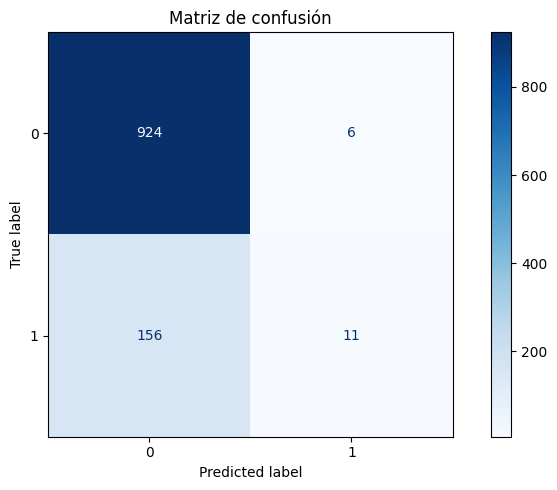

In [20]:
# ==========================================
# Matriz de confusión
# ==========================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Matriz de confusión")

plt.tight_layout()

plt.show()

In [21]:
# ==========================================
# Métricas del modelo
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

metricas = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score"

    ],

    "Valor":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

display(metricas.round(4))

,Métrica,Valor
0,Accuracy,0.8523
1,Precision,0.6471
2,Recall,0.0659
3,F1-score,0.1196


## Curva ROC y Área Bajo la Curva (AUC)

La curva ROC permite evaluar la capacidad discriminante del modelo para distinguir entre pacientes que desarrollan y no desarrollan enfermedad coronaria.

El Área Bajo la Curva (AUC) resume el desempeño global del clasificador independientemente del umbral de decisión utilizado.

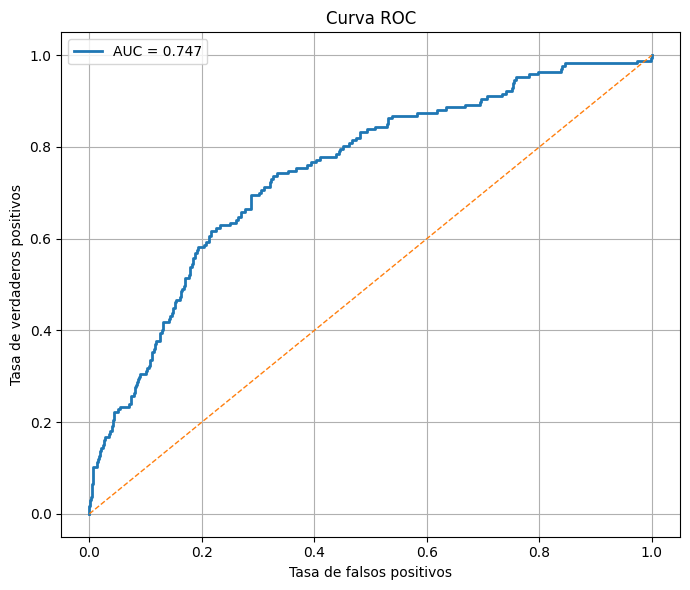

AUC = 0.7468


In [22]:
# ==========================================
# Curva ROC
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    linewidth=1
)

plt.xlabel("Tasa de falsos positivos")

plt.ylabel("Tasa de verdaderos positivos")

plt.title("Curva ROC")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("=" * 60)
print(f"AUC = {auc:.4f}")
print("=" * 60)

### Interpretación del desempeño

Como referencia general:

- AUC = 0.50: sin capacidad discriminante.
- 0.60–0.70: desempeño bajo.
- 0.70–0.80: desempeño aceptable.
- 0.80–0.90: buen desempeño.
- >0.90: desempeño excelente.

El valor obtenido será utilizado para evaluar la capacidad predictiva del modelo y servirá como línea base para comparar los modelos que se desarrollarán posteriormente durante la Sumativa 3.

In [23]:
# ==========================================
# Resumen del modelo
# ==========================================

resumen_modelo = pd.DataFrame({

    "Indicador":[

        "Número de predictores",

        "Variables significativas",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC"

    ],

    "Valor":[

        len(features),

        variables_significativas["Significativa"].eq("Sí").sum(),

        round(accuracy,4),

        round(precision,4),

        round(recall,4),

        round(f1,4),

        round(auc,4)

    ]

})

display(resumen_modelo)

,Indicador,Valor
0,Número de predictores,5.0000
1,Variables significativas,5.0000
2,Accuracy,0.8523
3,Precision,0.6471
4,Recall,0.0659
5,F1-score,0.1196
6,AUC,0.7468


# 7. Síntesis y reflexión

El modelo de regresión logística desarrollado permitió integrar los principales resultados obtenidos durante las Sumativas 1 y 2. La selección de variables se fundamentó en la evidencia estadística obtenida previamente, incorporando únicamente predictores con respaldo metodológico y verificando la ausencia de problemas importantes de multicolinealidad mediante el análisis del VIF.

El modelo alcanzó un desempeño aceptable (AUC = 0.7468), evidenciando una adecuada capacidad para discriminar entre pacientes con y sin enfermedad coronaria. No obstante, el bajo valor de Recall indica que una proporción importante de pacientes con enfermedad no fue correctamente identificada utilizando el umbral de clasificación de 0.5, situación esperable considerando el desbalance presente en el conjunto de datos.

Estos resultados constituyen una línea base para la siguiente etapa del proyecto. Durante la Sumativa 3 se evaluarán distintas estrategias de imputación de datos faltantes, se construirán modelos alternativos de regresión logística y se analizará la estabilidad de los coeficientes mediante bootstrap, con el objetivo de mejorar el desempeño predictivo y fortalecer la interpretación del modelo final.

# 8. Exportación de resultados

## Exportación automática de resultados

Con el propósito de facilitar la reproducibilidad del proyecto y preparar la información para la Sumativa 3, los principales resultados obtenidos durante esta actividad se exportan automáticamente.

Se almacenan tanto las tablas resumen como las principales visualizaciones generadas durante el análisis.

In [24]:
# ==========================================
# Exportación de tablas
# ==========================================

# Odds Ratio
odds_ratio.to_csv(
    RESULTS_DIR / "odds_ratio.csv",
    index=False,
    encoding="utf-8-sig"
)

# VIF
vif.to_csv(
    RESULTS_DIR / "vif.csv",
    index=False,
    encoding="utf-8-sig"
)

# Métricas
metricas.to_csv(
    RESULTS_DIR / "metricas_modelo.csv",
    index=False,
    encoding="utf-8-sig"
)

# Resumen
resumen_modelo.to_csv(
    RESULTS_DIR / "resumen_modelo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas exportadas correctamente.")

Tablas exportadas correctamente.


In [28]:
# ==========================================
# Exportación de predicciones
# ==========================================

predicciones = pd.DataFrame({
    "Real": y_test.values,
    "Probabilidad": y_prob,
    "Prediccion": y_pred
})

predicciones.to_csv(
    RESULTS_DIR / "predicciones_modelo.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Predicciones exportadas correctamente.")

Predicciones exportadas correctamente.


In [25]:
# ==========================================
# Exportación de la matriz de confusión
# ==========================================

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(cm)

disp.plot(ax=ax, cmap="Blues")

ax.set_title("Matriz de confusión")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "matriz_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Matriz de confusión exportada.")

Matriz de confusión exportada.


In [26]:
# ==========================================
# Exportación de la curva ROC
# ==========================================

fig, ax = plt.subplots(figsize=(7,6))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

ax.plot(
    [0,1],
    [0,1],
    "--"
)

ax.set_xlabel("Tasa de falsos positivos")

ax.set_ylabel("Tasa de verdaderos positivos")

ax.set_title("Curva ROC")

ax.legend()

ax.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "curva_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

print("Curva ROC exportada.")

Curva ROC exportada.


In [27]:
# ==========================================
# Archivos generados
# ==========================================

print("=" * 60)
print("Exportación finalizada")
print("=" * 60)

print("\nResultados:")

for archivo in sorted(RESULTS_DIR.glob("*")):
    print("•", archivo.name)

print("\nFiguras:")

for archivo in sorted(FIGURES_DIR.glob("*")):
    print("•", archivo.name)

Exportación finalizada

Resultados:
• metricas_modelo.csv
• odds_ratio.csv
• resumen_modelo.csv
• vif.csv

Figuras:
• curva_roc.png
• matriz_confusion.png
